# Clothing Size Recommendation Advice System


## 1. Introduction & Problem Statement

### Introduction
With the rapid growth of online shopping, selecting the correct clothing size has become a major challenge for consumers. Unlike physical stores, online platforms do not allow customers to try garments before purchasing, which often leads to incorrect size selection, dissatisfaction, and high return rates. These issues negatively impact user experience, increase operational costs for retailers, and contribute to environmental waste due to excessive shipping and returns.

Advances in machine learning provide an opportunity to address this problem by analyzing user attributes and historical feedback to generate personalized size recommendations. By learning patterns from previous customers’ body measurements, product characteristics, and fit feedback, an intelligent advice system can assist users in choosing the most appropriate clothing size with higher confidence and accuracy.

### Problem Statement
The goal of this project is to build a **supervised machine learning–based advice system** that recommends an appropriate clothing size based on user and product attributes. Given structured input features such as body measurements, garment type, brand, and customer fit feedback, the system aims to classify whether a recommended size will result in a **good fit**, **tight fit**, or **loose fit**.

This problem is formulated as a **multi-class classification task**, where the target variable represents the perceived fit of a clothing item. The system will serve as a decision-support tool that enhances the online shopping experience by reducing size-related uncertainty and minimizing product returns. In Phase 1, the focus is on understanding the problem domain, exploring the dataset, preprocessing the data, and developing supervised learning models to form a reliable foundation for future enhancements in Phase 2.



## 2. Dataset Selection & Justification

### Dataset Goal & Source
To support the development of the clothing size recommendation system, we selected the **Clothing Fit Dataset for Size Recommendation**, which is publicly available on **Kaggle**.

**Dataset URL:**  
https://www.kaggle.com/datasets/rmisra/clothing-fit-dataset-for-size-recommendation

The primary goal of this dataset is to capture real customer experiences with clothing fit in online shopping contexts. It contains user-provided information and feedback that can be leveraged to predict whether a selected clothing size fits well.

### Dataset Description
The dataset consists of several hundred thousand records and includes structured, tabular data suitable for supervised learning. Key attributes include:

- User characteristics (e.g., height, weight, age)
- Product-related features (e.g., clothing category, brand)
- Size information selected by the customer
- Customer feedback indicating perceived fit (e.g., fit, small, large)

The target variable represents the fit outcome, which aligns directly with the classification objective of this project.

### Justification for Dataset Selection
This dataset was selected for the following reasons:

**1. Relevance to the Problem Domain**  
The dataset directly addresses the challenge of clothing size recommendation by linking user attributes and product information to fit outcomes. This makes it highly suitable for building an advice system focused on fashion and lifestyle guidance.

**2. Sufficient Size and Feature Complexity**  
The dataset contains a large number of observations and more than the minimum required number of features (10–15), ensuring adequate complexity for meaningful exploratory data analysis and model training.

**3. Structured and Cleanable Format**  
The data is provided in a structured, tabular format, making it compatible with Python-based data analysis and machine learning libraries. While preprocessing is required (e.g., handling missing values and encoding categorical variables), the dataset is well-suited for systematic cleaning and feature engineering.

**4. Clear Classification Labels**  
The presence of multiple fit categories enables the formulation of a multi-class classification problem, which satisfies the project requirement of having at least two classes and allows for richer evaluation and comparison of supervised learning algorithms.

**5. Real-World Applicability**  
Because the data is derived from real customer feedback, the resulting model has strong practical relevance and can be extended in Phase 2 to incorporate clustering and Generative AI for personalized explanations and recommendations.



## 3. Initial Data Inspection

In this section, we perform an initial inspection of the dataset to understand the number of observations, features, data types, and the target variable (`fit`). This step helps identify missing values, mixed data types, and general structure before further exploratory data analysis.


✅ Dataset loaded successfully!

📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  str    
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  str    
 8   bust            11854 non-null  str    
 9   height          81683 non-null  str    
 10  user_name       82790 non-null  str    
 11  length          82755 non-null  str    
 12  fit             82790 non-null  str    
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  str    
 16  review_summary  76058 non-null  str    

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN



🔢 Statistical summary of numeric columns:


,item_id,waist,size,quality,hips,bra size,user_id,shoe size
count,82790.000000,2882.000000,82790.000000,82722.000000,56064.000000,76772.000000,82790.000000,27915.000000
mean,469325.229170,31.319223,12.661602,3.949058,40.358501,35.972125,498849.564718,8.145818
std,213999.803314,5.302849,8.271952,0.992783,5.827166,3.224907,286356.969459,1.336109
min,123373.000000,20.000000,0.000000,1.000000,30.000000,28.000000,6.000000,5.000000
25%,314980.000000,28.000000,8.000000,3.000000,36.000000,34.000000,252897.750000,7.000000
50%,454030.000000,30.000000,12.000000,4.000000,39.000000,36.000000,497913.500000,8.000000
75%,658440.000000,34.000000,15.000000,5.000000,43.000000,38.000000,744745.250000,9.000000
max,807722.000000,50.000000,38.000000,5.000000,60.000000,48.000000,999972.000000,38.000000



❗ Missing values per column:


item_id               0
waist             79908
size                  0
quality              68
cup size           6255
hips              26726
bra size           6018
category              0
bust              70936
height             1107
user_name             0
length               35
fit                   0
user_id               0
shoe size         54875
shoe width        64183
review_summary     6732
review_text        6732
dtype: int64

🎯 Target Variable ('fit') Classes Overview:
- Class 'fit': 56757 samples (68.56%)
- Class 'large': 13059 samples (15.77%)
- Class 'small': 12974 samples (15.67%)


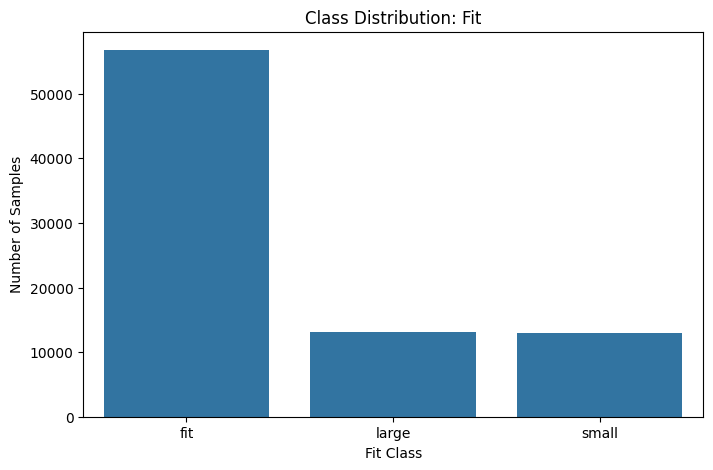

📝 Description: This plot shows the distribution of the target variable 'fit'. It indicates how many samples belong to each class (Fit, Small, Large).
Statistical Summary of Numeric Features:


,bust,waist,hips,height,bra size,shoe size
count,11853.000000,2882.000000,56064.000000,0.0,76772.000000,27915.000000
mean,37.499199,31.319223,40.358501,NaN,35.972125,8.145818
std,4.635310,5.302849,5.827166,NaN,3.224907,1.336109
min,20.000000,20.000000,30.000000,NaN,28.000000,5.000000
25%,34.000000,28.000000,36.000000,NaN,34.000000,7.000000
50%,36.000000,30.000000,39.000000,NaN,36.000000,8.000000
75%,40.000000,34.000000,43.000000,NaN,38.000000,9.000000
max,59.000000,50.000000,60.000000,NaN,48.000000,38.000000


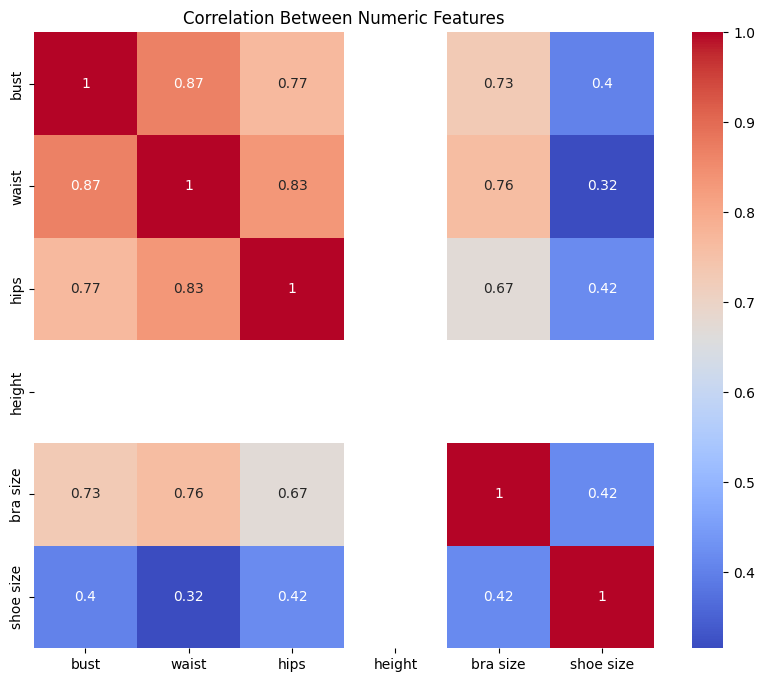

This heatmap shows the Pearson correlation coefficients between numeric features. Values close to 1 or -1 indicate strong correlation.


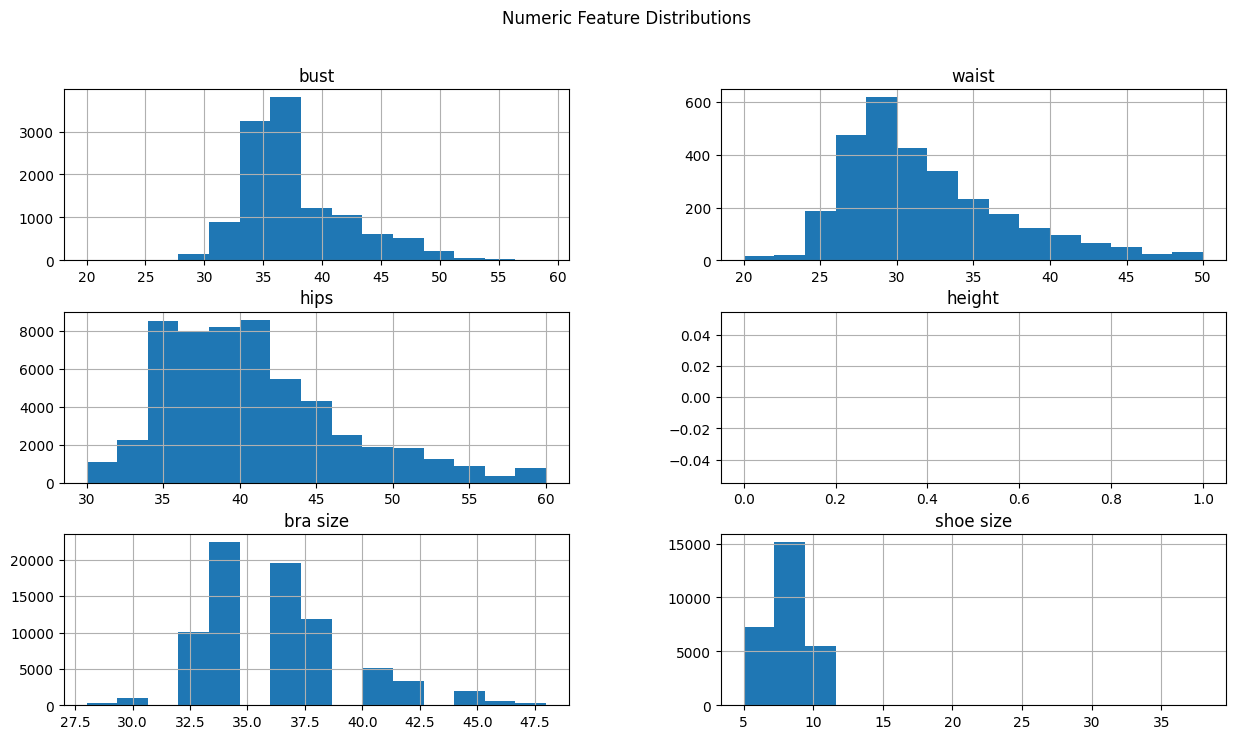

This Histograms display the distribution of numeric features. We can observe the spread, skewness, and outliers in the data.


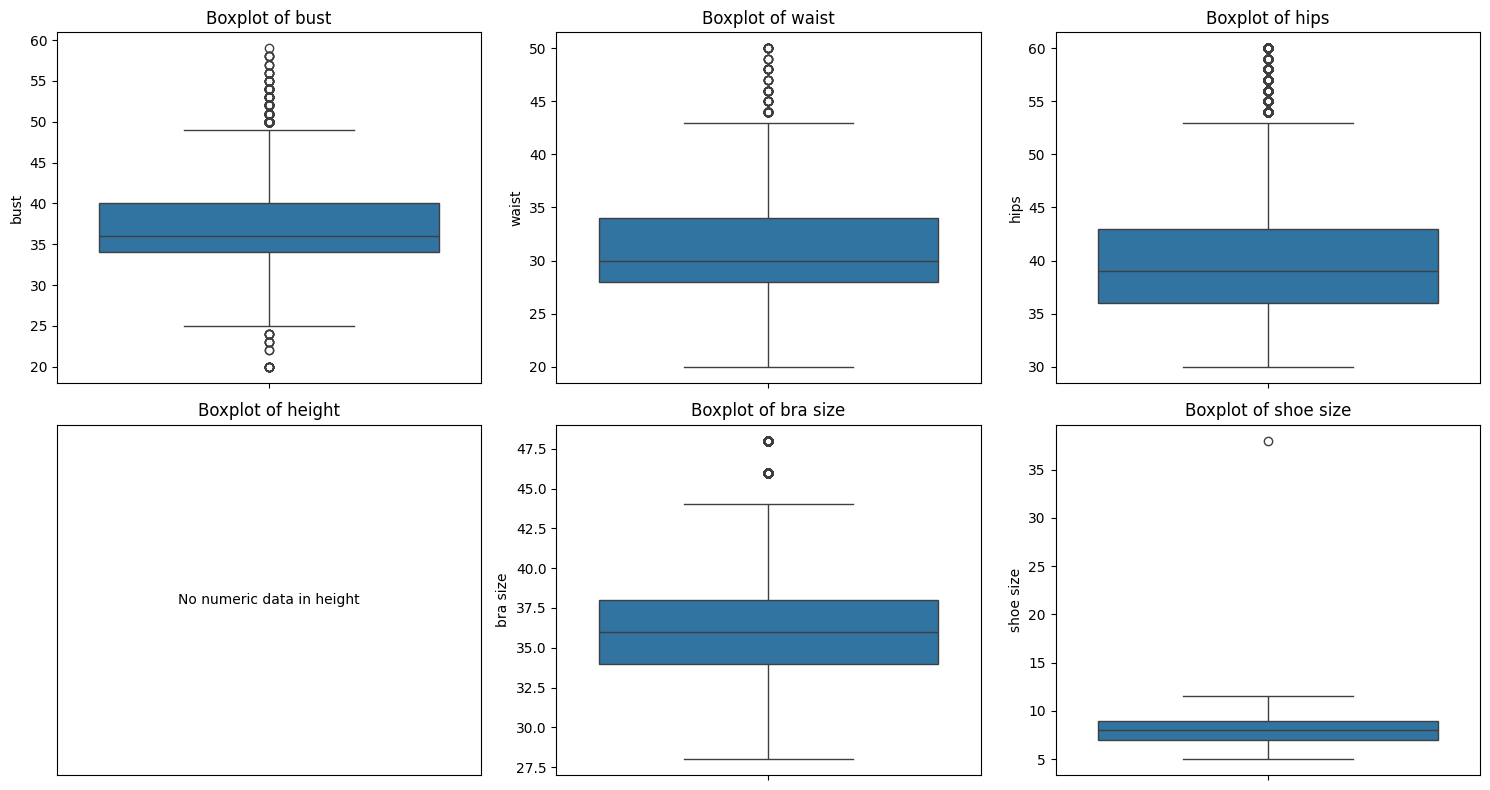

These Boxplots help visualize the distribution, median, and potential outliers for each numeric feature.


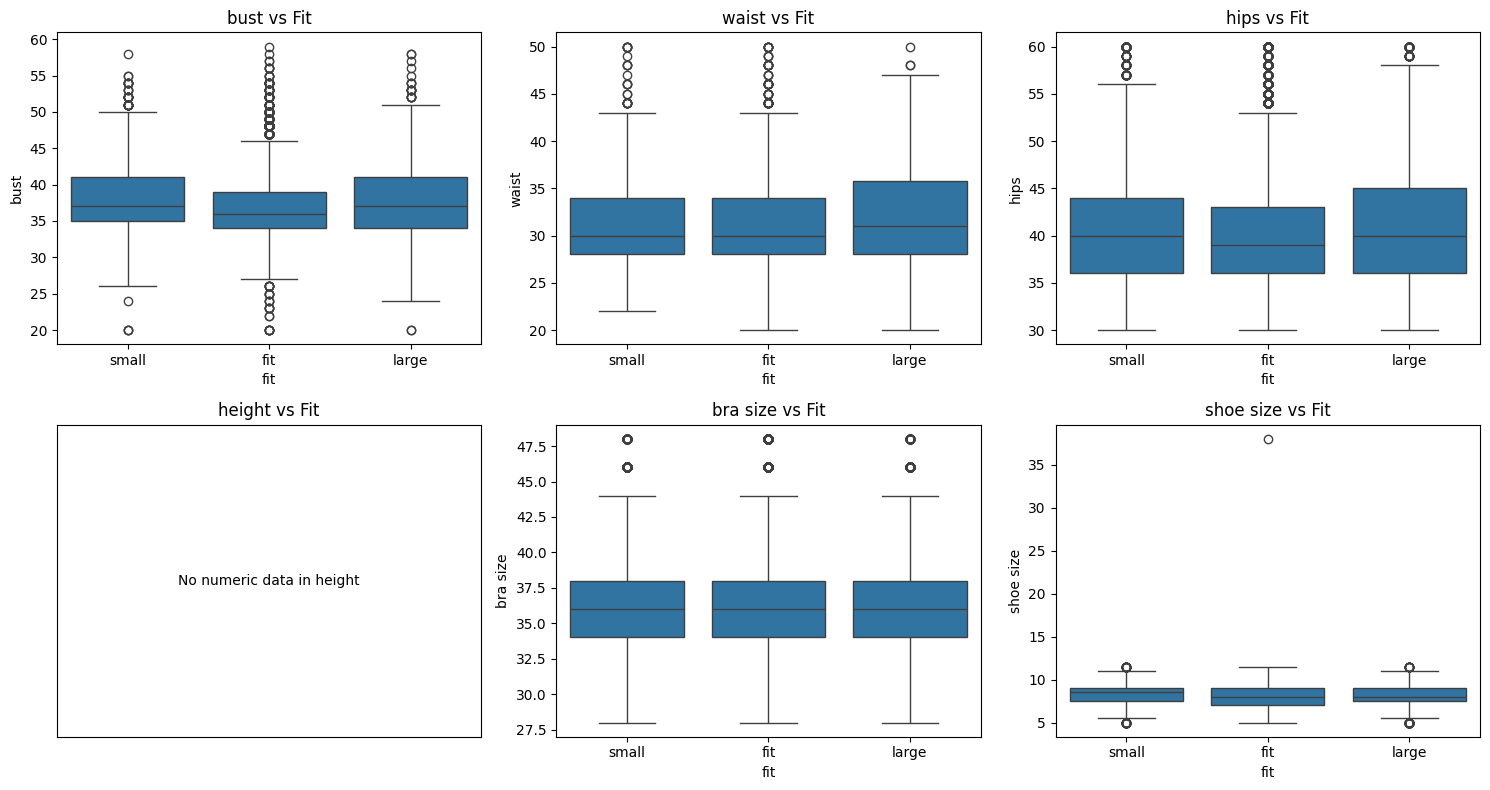

These boxplots show how each numeric feature relates to the target variable 'fit'. We can see if certain features differ across Fit, Small, and Large classes.


In [ ]:
# ---------------------------
# 1️⃣ Import Libraries
# ---------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# لجعل الرسوم تظهر مباشرة في Jupyter
%matplotlib inline

# ---------------------------
# 2️⃣ Load Dataset
# ---------------------------
modcloth_df = pd.read_csv(
    r'D:\AI-SWE485-Project\Dataset\modcloth_final_data.csv',
    low_memory=False
)

print("✅ Dataset loaded successfully!\n")

# ---------------------------
# 3️⃣ Dataset Overview
# ---------------------------
print("📊 Dataset Info:")
modcloth_df.info()

print("\n📝 First 5 rows of the dataset:")
display(modcloth_df.head())

print("\n🔢 Statistical summary of numeric columns:")
display(modcloth_df.describe())

print("\n❗ Missing values per column:")
display(modcloth_df.isnull().sum())

# ---------------------------
# 4️⃣ Target Variable ('fit') Overview
# ---------------------------
fit_counts = modcloth_df['fit'].value_counts()
fit_percent = modcloth_df['fit'].value_counts(normalize=True) * 100

print("🎯 Target Variable ('fit') Classes Overview:")
for cls in fit_counts.index:
    print(f"- Class '{cls}': {fit_counts[cls]} samples ({fit_percent[cls]:.2f}%)")

# رسم توزيع الفئات
plt.figure(figsize=(8,5))
sns.countplot(x='fit', data=modcloth_df, order=fit_counts.index)
plt.title("Class Distribution: Fit")
plt.xlabel("Fit Class")
plt.ylabel("Number of Samples")
plt.show()
print("📝 Description: This plot shows the distribution of the target variable 'fit'. It indicates how many samples belong to each class (Fit, Small, Large).")

# ---------------------------
# Feature Analysis
# ---------------------------

# قائمة الأعمدة الرقمية المهمة
numeric_cols = ['bust', 'waist', 'hips', 'height', 'bra size', 'shoe size']

# 5.0 Clean numeric columns: تحويل أي قيمة غير رقمية إلى NaN
for col in numeric_cols:
    modcloth_df[col] = pd.to_numeric(modcloth_df[col], errors='coerce')

# 5.1 Statistical Summaries
print("Statistical Summary of Numeric Features:")
display(modcloth_df[numeric_cols].describe())

# 5.2 Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(modcloth_df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()
print("This heatmap shows the Pearson correlation coefficients between numeric features. Values close to 1 or -1 indicate strong correlation.")

# 5.3 Feature Distributions - Histograms
modcloth_df[numeric_cols].hist(bins=15, figsize=(15,8))
plt.suptitle("Numeric Feature Distributions")
plt.show()
print("These Histograms display the distribution of numeric features. We can observe the spread, skewness, and outliers in the data.")

# 5.4 Feature Distributions - Boxplots
plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    
    # نتأكد أن العمود يحتوي على قيم رقمية
    if modcloth_df[col].dropna().empty:
        plt.text(0.5, 0.5, f"No numeric data in {col}", ha='center', va='center')
        plt.title(f"Boxplot of {col}")
        plt.xticks([])
        plt.yticks([])
        continue
    
    sns.boxplot(y=modcloth_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()
print("These Boxplots help visualize the distribution, median, and potential outliers for each numeric feature.")

# 5.5 Relationships Between Features and Target ('fit')
plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    
    if modcloth_df[col].dropna().empty:
        plt.text(0.5, 0.5, f"No numeric data in {col}", ha='center', va='center')
        plt.title(f"{col} vs Fit")
        plt.xticks([])
        plt.yticks([])
        continue
    
    sns.boxplot(x='fit', y=col, data=modcloth_df)
    plt.title(f"{col} vs Fit")
plt.tight_layout()
plt.show()
print("These boxplots show how each numeric feature relates to the target variable 'fit'. We can see if certain features differ across Fit, Small, and Large classes.")
